# Breast Cancer Classification Using Logistic Regression (From Scratch with NumPy & Pandas)

A machine learning project implementing Logistic Regression from first principles using only Python, NumPy, and Pandas—without relying on any external machine learning libraries.


<h2>Step 1: Import Required Libraries</h2>
<p>In this step, we import the essential Python libraries needed for building the Logistic Regression model from scratch. <strong>NumPy</strong> is used for efficient numerical computations, <strong>Pandas</strong> helps in handling and manipulating the dataset, <strong>Math</strong> is used for basic mathematical operations, and <strong>Random</strong> assists in initializing parameters. Additionally, <strong>Matplotlib</strong> is used for visualizing the cost function and model performance during training.</p>


In [36]:
import numpy as np
import pandas as pd
import math
import random
import matplotlib.pyplot as plt

<h2>Step 2: Load the Dataset</h2>
<p>In this step, we load the Breast Cancer dataset into a Pandas DataFrame using the <code>read_csv()</code> function. This allows us to work with the data in a structured tabular format. The <code>head()</code> function is then used to display the first few rows of the dataset, helping us understand its structure, column names, and initial values.</p>


In [2]:
df=pd.read_csv("D:\dataR2.csv")
df.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


<h2>Step 3: Understand the Dataset</h2>
<p>In this step, we explore the dataset to gain a better understanding of its structure and content. The <code>info()</code> function provides details about the data types, non-null values, and overall structure of the dataset. The <code>describe()</code> function gives statistical summaries such as mean, standard deviation, minimum, and maximum values for numerical columns. Finally, <code>shape</code> is used to determine the number of rows and columns in the dataset.</p>


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB


In [4]:
df.describe()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,1.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,1.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,1.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,2.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,2.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,2.000000


In [5]:
df.shape

(116, 10)

<h2>Step 4: Check for Missing Values</h2>
<p>In this step, we check whether the dataset contains any missing or null values. The <code>isnull().sum()</code> function is used to count the number of missing values in each column. This helps us identify if any data cleaning or preprocessing is required before building the Logistic Regression model.</p>


In [38]:
df.isnull().sum()

Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    0
label             0
dtype: int64

<h2>Step 5: Data Visualization and Understanding Feature Behavior</h2>
<p>In this step, we perform data visualization to better understand how different features behave across the two classes (Healthy and Cancer). Histograms are plotted for multiple features, allowing us to observe the distribution and separation between classes, which is crucial for classification tasks.</p>

<p>Additionally, we visualize the <strong>Sigmoid Function</strong>, which is the core of Logistic Regression. The sigmoid curve shows how input values are transformed into probabilities between 0 and 1. We also plot its gradient to understand how the model learns during training, as the gradient determines how weights are updated during gradient descent.</p>

<p>These visualizations help build intuition about how Logistic Regression makes decisions and how well the features can separate the two classes.</p>


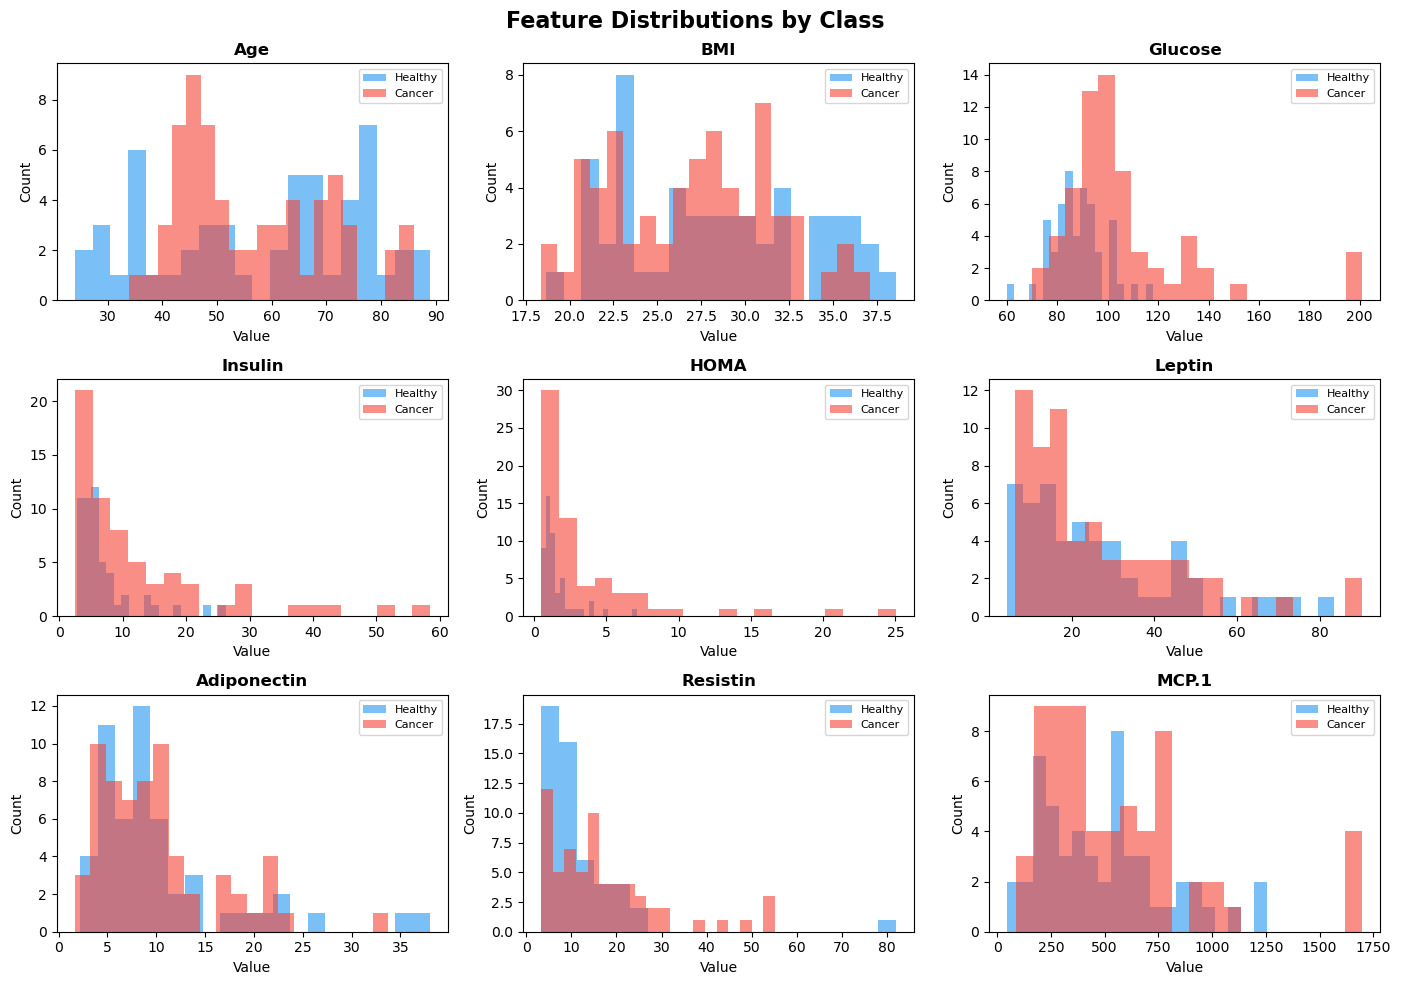

In [39]:
#1. Class Distribution Bar Chart 
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Feature Distributions by Class", fontsize=16, fontweight='bold')

colors = {0: '#2196F3', 1: '#F44336'}  # blue = healthy, red = cancer
labels = {0: 'Healthy', 1: 'Cancer'}

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i // 3][i % 3]
    for cls in [0, 1]:
        mask = y == cls
        ax.hist(X_raw[mask, i], bins=20, alpha=0.6,
                color=colors[cls], label=labels[cls])
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

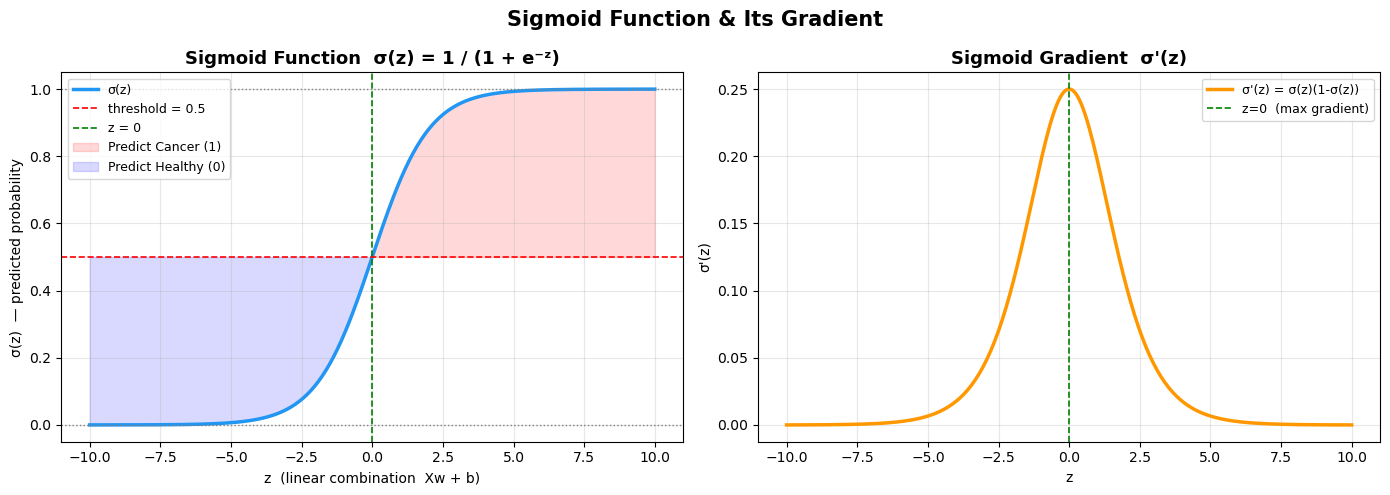

In [40]:
# Sigmoid curve 
z    = np.linspace(-10, 10, 300)
sig  = sigmoid(z)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — full sigmoid curve
ax = axes[0]
ax.plot(z, sig, color='#2196F3', linewidth=2.5, label='σ(z)')
ax.axhline(0.5, color='red',   linestyle='--', linewidth=1.2, label='threshold = 0.5')
ax.axhline(1.0, color='gray',  linestyle=':',  linewidth=1)
ax.axhline(0.0, color='gray',  linestyle=':',  linewidth=1)
ax.axvline(0.0, color='green', linestyle='--', linewidth=1.2, label='z = 0')
ax.fill_between(z, 0.5, sig, where=(sig >= 0.5),
                alpha=0.15, color='red',   label='Predict Cancer (1)')
ax.fill_between(z, sig, 0.5, where=(sig <  0.5),
                alpha=0.15, color='blue',  label='Predict Healthy (0)')
ax.set_title("Sigmoid Function  σ(z) = 1 / (1 + e⁻ᶻ)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("z  (linear combination  Xw + b)")
ax.set_ylabel("σ(z)  — predicted probability")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# Plot 2 — gradient of sigmoid  (σ'(z) = σ(z)(1 - σ(z)))
sig_grad = sig * (1 - sig)
ax2 = axes[1]
ax2.plot(z, sig_grad, color='#FF9800', linewidth=2.5, label="σ'(z) = σ(z)(1-σ(z))")
ax2.axvline(0.0, color='green', linestyle='--', linewidth=1.2, label='z=0  (max gradient)')
ax2.set_title("Sigmoid Gradient  σ'(z)",
              fontsize=13, fontweight='bold')
ax2.set_xlabel("z")
ax2.set_ylabel("σ'(z)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Sigmoid Function & Its Gradient", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

<h2>Step 6: Feature Selection and Label Encoding</h2>
<p>In this step, we prepare the data for model training by selecting relevant features and encoding the target variable. The <code>Classification</code> column is mapped into a binary label format where <code>0</code> represents Healthy and <code>1</code> represents Cancer, making it suitable for Logistic Regression.</p>

<p>We then define a list of important feature columns and extract them into <code>X_raw</code>, which represents the input features. The target variable is stored in <code>y</code>. This step ensures that the dataset is properly structured into input features and corresponding labels for model training.</p>


In [7]:
df["label"] = df["Classification"].map({1: 0, 2: 1})

In [8]:
FEATURE_COLS = ["Age", "BMI", "Glucose", "Insulin", "HOMA",
                "Leptin", "Adiponectin", "Resistin", "MCP.1"]
 
X_raw = df[FEATURE_COLS].values   # shape (116, 9)
y     = df["label"].values 

<h2>Step 7: Feature Scaling using Normalization</h2>
<p>In this step, we define a function to normalize the input features using <strong>Z-score normalization</strong>. This technique scales the data such that each feature has a mean of 0 and a standard deviation of 1, which helps improve the performance and convergence speed of the Logistic Regression model.</p>

<p>The function computes the mean and standard deviation of the dataset if they are not provided. It also ensures numerical stability by avoiding division by zero using a safe standard deviation. The normalized data, along with the computed mean and standard deviation, is returned for further use.</p>


In [9]:
def normalise(X, mean=None, std=None):
    """Z-score normalise. Computes stats from X if not provided."""
    if mean is None:
        mean = X.mean(axis=0)
    if std is None:
        std  = X.std(axis=0)
    std_safe = np.where(std == 0, 1, std)   # avoid division-by-zero
    return (X - mean) / std_safe, mean, std

In [10]:
X_norm, feature_mean, feature_std = normalise(X_raw)
 
print("Feature Normalisation (Z-score):")
print(f"  Mean  (first 3): {feature_mean[:3].round(3)}")
print(f"  Std   (first 3): {feature_std[:3].round(3)}")
print(f"\n  X_norm sample (row 0): {X_norm[0].round(4)}")

Feature Normalisation (Z-score):
  Mean  (first 3): [57.302 27.582 97.793]
  Std   (first 3): [16.043  4.998 22.428]

  X_norm sample (row 0): [-0.5798 -0.8167 -1.2392 -0.7287 -0.6143 -0.9323 -0.0702 -0.5455 -0.3413]


<h2>Step 8: Train-Test Split</h2>
<p>In this step, we split the dataset into training and testing sets to evaluate the performance of our Logistic Regression model. First, we set a random seed to ensure reproducibility of results. The dataset is then shuffled using a random permutation of indices to avoid any bias due to ordering.</p>

<p>We allocate 80% of the data for training and the remaining 20% for testing. The training set (<code>X_train</code>, <code>y_train</code>) is used to learn the model parameters, while the testing set (<code>X_test</code>, <code>y_test</code>) is used to evaluate how well the model generalizes to unseen data.</p>


In [13]:
np.random.seed(42)
X=X_norm
m=len(X)

indices= np.random.permutation(m)

#80% of the samples used for training 
train_size= int(0.8*m)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

<h2>Step 9: Define the Sigmoid Function</h2>
<p>In this step, we define the <strong>sigmoid function</strong>, which is the core component of Logistic Regression. It takes any real-valued input <code>z</code> and transforms it into a value between 0 and 1, representing a probability.</p>

<p>This function is used to map the linear combination of inputs (<code>Xw + b</code>) into a probability that the given input belongs to a particular class. Values closer to 1 indicate a higher likelihood of the positive class (Cancer), while values closer to 0 indicate the negative class (Healthy).</p>


In [14]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

<h2>Step 10: Define the Cost Function (Log Loss)</h2>
<p>In this step, we define the cost function used to evaluate how well our Logistic Regression model is performing. The cost function used here is <strong>Log Loss (Binary Cross-Entropy Loss)</strong>, which measures the difference between the actual labels and the predicted probabilities.</p>

<p>First, we compute the linear combination of inputs: <code>z = Xw + b</code>. Then, we apply the sigmoid function to obtain predicted probabilities. A small value (<code>eps</code>) is added to avoid numerical issues like <code>log(0)</code>.</p>

<p><strong>Mathematical Formulation:</strong></p>
<p>
Linear Combination:<br>
<code>z = Xw + b</code>
</p>

<p>
Sigmoid Function:<br>
<code>ŷ = 1 / (1 + e<sup>-z</sup>)</code>
</p>

<p>
Cost Function (Log Loss):<br>
<code>
J(w, b) = -(1/m) * Σ [ y log(ŷ) + (1 - y) log(1 - ŷ) ]
</code>
</p>

<p>This function penalizes incorrect predictions more heavily, helping the model learn better decision boundaries during training.</p>


In [15]:
def compute_cost(X, y, w, b):
    m   = len(y)
    z   = X @ w + b            # linear combination  (m,)
    yh  = sigmoid(z)           # predicted probability (m,)
    eps = 1e-9                 # small value to avoid log(0)
    cost = -(1/m) * np.sum(
        y * np.log(yh + eps) + (1 - y) * np.log(1 - yh + eps)
    )
    return cost

<h2>Step 11: Compute Gradients for Optimization</h2>
<p>In this step, we compute the gradients of the cost function with respect to the model parameters (<code>w</code> and <code>b</code>). These gradients are essential for updating the parameters during Gradient Descent.</p>

<p>First, we calculate the predicted probabilities using the sigmoid function. Then, we compute the error as the difference between predicted values and actual labels. Using this error, we calculate the gradients for weights and bias.</p>

<p><strong>Mathematical Formulation:</strong></p>

<p>
Error:<br>
<code>error = ŷ − y</code>
</p>

<p>
Gradient w.r.t Weights:<br>
<code>dw = (1/m) * X<sup>T</sup>(ŷ − y)</code>
</p>

<p>
Gradient w.r.t Bias:<br>
<code>db = (1/m) * Σ(ŷ − y)</code>
</p>

<p>These gradients indicate the direction in which the parameters should be adjusted to minimize the cost function.</p>


In [41]:
def compute_gradient(X, y, w, b):
    m   = len(y)
    z   = X @ w + b
    yh  = sigmoid(z)
    err = yh - y               # prediction error  (m,)
 
    dw  = (1/m) * (X.T @ err) # gradient w.r.t. weights  (n,)
    db  = (1/m) * np.sum(err)  # gradient w.r.t. bias  (scalar)
    return dw, db

<h2>Step 12: Train the Model using Gradient Descent</h2>
<p>In this step, we implement the <strong>Gradient Descent algorithm</strong> to train our Logistic Regression model. The goal of this process is to iteratively update the model parameters (<code>w</code> and <code>b</code>) in order to minimize the cost function.</p>

<p>We start by initializing the weights to zero and the bias to zero. Then, for a fixed number of iterations, we compute the gradients and update the parameters using the learning rate. The learning rate controls how big a step we take during each update.</p>

<p><strong>Parameter Update Equations:</strong></p>

<p>
<code>w = w − α · dw</code><br>
<code>b = b − α · db</code>
</p>

<p>Where <code>α</code> is the learning rate.</p>

<p>We also keep track of the cost at regular intervals (every 100 iterations) to monitor how the model is learning over time. This helps in visualizing convergence and ensuring that the cost is decreasing as expected.</p>


In [42]:
def gradient_descent(X, y, learning_rate=0.1, num_iterations=1000):
    n          = X.shape[1]
    w          = np.zeros(n)   # initialise weights to zero
    b          = 0.0           # initialise bias to zero
    cost_history = []
 
    for i in range(num_iterations):
        dw, db = compute_gradient(X, y, w, b)
        w -= learning_rate * dw
        b -= learning_rate * db
 
        # Record cost every 100 iterations
        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            cost_history.append((i, cost))
 
    return w, b, cost_history

<h2>Step 13: Train the Model and Monitor Cost Reduction</h2>
<p>In this step, we train the Logistic Regression model by calling the <code>gradient_descent</code> function with specified hyperparameters such as the learning rate and number of iterations.</p>

<p>The model learns the optimal weights (<code>w_trained</code>) and bias (<code>b_trained</code>) that minimize the cost function. After training, we print a summary of the training process, including the total number of iterations and the learning rate used.</p>

<p>Additionally, we display the cost values recorded at every 100 iterations. This helps us observe how the cost decreases over time, indicating that the model is learning and converging toward an optimal solution.</p>


In [18]:
LEARNING_RATE  = 0.01
NUM_ITERATIONS = 2000
 
w_trained, b_trained, cost_hist = gradient_descent(
    X_train, y_train,
    learning_rate  = LEARNING_RATE,
    num_iterations = NUM_ITERATIONS
)
 
print(f"Training complete — {NUM_ITERATIONS} iterations, α = {LEARNING_RATE}")
print("\nCost at every 100 iterations:")
print(f"  {'Iteration':>10}  {'Cost':>10}")
print("  " + "-" * 24)
for iteration, cost in cost_hist:
    print(f"  {iteration:>10}  {cost:>10.6f}")

Training complete — 2000 iterations, α = 0.01

Cost at every 100 iterations:
   Iteration        Cost
  ------------------------
           0    0.692354
         100    0.634366
         200    0.599643
         300    0.575484
         400    0.557365
         500    0.543161
         600    0.531684
         700    0.522199
         800    0.514217
         900    0.507403
        1000    0.501516
        1100    0.496377
        1200    0.491853
        1300    0.487841
        1400    0.484260
        1500    0.481044
        1600    0.478144
        1700    0.475515
        1800    0.473123
        1900    0.470940


<h2>Step 14: Make Predictions Using the Trained Model</h2>
<p>In this step, we define a function to make predictions using the trained Logistic Regression model. The function computes the predicted probabilities by applying the sigmoid function to the linear combination of inputs (<code>Xw + b</code>).</p>

<p>A threshold value (default = 0.5) is used to convert these probabilities into binary class labels. If the predicted probability is greater than or equal to the threshold, the output is classified as <code>1</code> (Cancer); otherwise, it is classified as <code>0</code> (Healthy).</p>

<p>The function returns both the predicted class labels and the corresponding probabilities, allowing us to evaluate the model and interpret its confidence in predictions.</p>


In [26]:
def predict(X, w, b, threshold=0.5):
    probs = sigmoid(X @ w + b)
    return (probs >= threshold).astype(int), probs

<h2>Step 15: Evaluate Model Performance</h2>
<p>In this step, we evaluate the performance of our trained Logistic Regression model using various classification metrics. First, we compute the <strong>confusion matrix</strong>, which shows the number of correct and incorrect predictions made by the model:</p>

<ul>
<li><strong>True Positives (TP):</strong> Correctly predicted Cancer cases</li>
<li><strong>True Negatives (TN):</strong> Correctly predicted Healthy cases</li>
<li><strong>False Positives (FP):</strong> Healthy predicted as Cancer</li>
<li><strong>False Negatives (FN):</strong> Cancer predicted as Healthy</li>
</ul>

<p>Using these values, we calculate key evaluation metrics:</p>

<ul>
<li><strong>Accuracy:</strong> Overall correctness of the model</li>
<li><strong>Precision:</strong> How many predicted Cancer cases are actually Cancer</li>
<li><strong>Recall:</strong> How many actual Cancer cases were correctly identified</li>
<li><strong>F1-Score:</strong> Harmonic mean of Precision and Recall</li>
</ul>

<p>Finally, we test the model on the training dataset by generating predictions and passing them to the evaluation function. This gives us a clear understanding of how well the model has learned from the training data.</p>


In [43]:
def evaluate(y_true, y_pred):
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))
    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))
 
    total     = TP + TN + FP + FN
    accuracy  = (TP + TN) / total
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
 
    print("CONFUSION MATRIX")
    print("─" * 35)
    print(f"                  Predicted 0  Predicted 1")
    print(f"  Actual 0 (Healthy) :   {TN:4d}        {FP:4d}")
    print(f"  Actual 1 (Cancer)  :   {FN:4d}        {TP:4d}")
    print("─" * 35)
    print(f"\n  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
 
    return accuracy, precision, recall, f1

In [46]:
print("=" * 55)
print("  TRAINING SET PERFORMANCE")
print("=" * 55)
y_pred_train, _ = predict(X_train, w_trained, b_trained)
evaluate(y_train, y_pred_train)

  TRAINING SET PERFORMANCE
CONFUSION MATRIX
───────────────────────────────────
                  Predicted 0  Predicted 1
  Actual 0 (Healthy) :     33          10
  Actual 1 (Cancer)  :     12          37
───────────────────────────────────

  Accuracy  : 0.7609  (76.09%)
  Precision : 0.7872
  Recall    : 0.7551
  F1-Score  : 0.7708


(0.7608695652173914,
 0.7872340425531915,
 0.7551020408163265,
 0.7708333333333333)

In [29]:
print("=" * 55)
print("  LEARNED WEIGHTS  (proxy for feature importance)")
print("  Positive → pushes toward cancer prediction")
print("  Negative → pushes toward healthy prediction")
print("=" * 55)
print(f"\n  {'Feature':15s}  {'Weight':>10}")
print("  " + "-" * 28)
for feat, wt in zip(FEATURE_COLS, w_trained):
    direction = "→ cancer ↑" if wt > 0 else "→ healthy ↑"
    print(f"  {feat:15s}  {wt:>10.4f}   {direction}")
print(f"\n  Bias (b)  :  {b_trained:.4f}")
 

  LEARNED WEIGHTS  (proxy for feature importance)
  Positive → pushes toward cancer prediction
  Negative → pushes toward healthy prediction

  Feature              Weight
  ----------------------------
  Age                 -0.0792   → healthy ↑
  BMI                 -0.6580   → healthy ↑
  Glucose              1.2566   → cancer ↑
  Insulin              0.1084   → cancer ↑
  HOMA                 0.2434   → cancer ↑
  Leptin               0.0165   → cancer ↑
  Adiponectin          0.0902   → cancer ↑
  Resistin             1.0412   → cancer ↑
  MCP.1                0.0097   → cancer ↑

  Bias (b)  :  0.3955


<h2>Step 17: Predict for a New Patient</h2>
<p>In this final step, we use the trained Logistic Regression model to make predictions on new, unseen data. A new patient’s details are provided in the form of a dictionary, where each feature value corresponds to the input variables used during training.</p>

<p>The input data is first arranged in the correct feature order and then normalized using the same mean and standard deviation calculated from the training data. This ensures consistency between training and prediction phases.</p>

<p>The model then computes the probability of the patient having cancer using the sigmoid function. Based on a threshold (default = 0.5), the probability is converted into a final prediction:</p>

<ul>
<li><strong>Probability ≥ 0.5:</strong> Cancer detected</li>
<li><strong>Probability &lt; 0.5:</strong> Healthy (no cancer)</li>
</ul>

<p>This step demonstrates how the model can be applied in real-world scenarios to assist in predicting outcomes for new patients.</p>


In [30]:
def predict_new_patient(values_dict, w, b, mean, std, feature_cols,
                        threshold=0.5):

    # Build raw feature vector in correct column order
    raw = np.array([values_dict[col] for col in feature_cols], dtype=float)
 
    # Apply same normalisation as training data
    x_norm, _, _ = normalise(raw.reshape(1, -1), mean=mean, std=std)
 
    # Compute probability & class
    prob  = sigmoid(x_norm @ w + b)[0]
    label = int(prob >= threshold)
 
    return label, prob

In [31]:
new_patient_1 = {
    "Age"         : 48,
    "BMI"         : 23.5,
    "Glucose"     : 70,
    "Insulin"     : 2.707,
    "HOMA"        : 0.467,
    "Leptin"      : 8.8071,
    "Adiponectin" : 9.702,
    "Resistin"    : 7.996,
    "MCP.1"       : 417.1,
}
 
label_1, prob_1 = predict_new_patient(
    new_patient_1, w_trained, b_trained,
    feature_mean, feature_std, FEATURE_COLS
)
 
print("=" * 55)
print("  NEW PATIENT PREDICTION — EXAMPLE 1")
print("=" * 55)
for feat, val in new_patient_1.items():
    print(f"  {feat:15s}: {val}")
print()
print(f"  Cancer probability : {prob_1:.4f}  ({prob_1*100:.2f}%)")
print(f"  Prediction         : {'⚠️  CANCER DETECTED' if label_1 == 1 else '✅  HEALTHY  (no cancer)'}")
 

  NEW PATIENT PREDICTION — EXAMPLE 1
  Age            : 48
  BMI            : 23.5
  Glucose        : 70
  Insulin        : 2.707
  HOMA           : 0.467
  Leptin         : 8.8071
  Adiponectin    : 9.702
  Resistin       : 7.996
  MCP.1          : 417.1

  Cancer probability : 0.1978  (19.78%)
  Prediction         : ✅  HEALTHY  (no cancer)


<h2>Step 18: Interactive Prediction System</h2>
<p>In this step, we build an interactive prediction system that allows users to input patient details manually and obtain real-time predictions from the trained Logistic Regression model.</p>

<p>For each feature, the user is prompted to enter a value. If no input is provided, a default value (calculated as the mean of that feature from the training data) is used. This ensures that the model can still make a prediction even if some inputs are skipped.</p>

<p>The entered values are then processed, normalized using the same training statistics, and passed through the model to compute the probability of cancer. Based on this probability, a final prediction is displayed.</p>

<p>This step demonstrates how the model can be converted into a simple user-interactive tool, making it more practical and usable in real-world applications.</p>


In [32]:
print("\n" + "=" * 55)
print("  INTERACTIVE PREDICTION")
print("  (Enter patient values — press Enter to use defaults)")
print("=" * 55)
 
# Defaults (mean of the dataset — a "typical" patient)
DEFAULTS = {col: round(float(feature_mean[i]), 2)
            for i, col in enumerate(FEATURE_COLS)}
 
new_patient_2 = {}
for col in FEATURE_COLS:
    raw_input = input(f"  {col:15s} [default {DEFAULTS[col]}]: ").strip()
    new_patient_2[col] = float(raw_input) if raw_input else DEFAULTS[col]
 
label_2, prob_2 = predict_new_patient(
    new_patient_2, w_trained, b_trained,
    feature_mean, feature_std, FEATURE_COLS
)
 
print()
print(f"  Cancer probability : {prob_2:.4f}  ({prob_2*100:.2f}%)")
print(f"  Prediction         : {'⚠️  CANCER DETECTED' if label_2 == 1 else '✅  HEALTHY  (no cancer)'}")
 


  INTERACTIVE PREDICTION
  (Enter patient values — press Enter to use defaults)


  Age             [default 57.3]:  
  BMI             [default 27.58]:  
  Glucose         [default 97.79]:  
  Insulin         [default 10.01]:  
  HOMA            [default 2.69]:  
  Leptin          [default 26.62]:  
  Adiponectin     [default 10.18]:  
  Resistin        [default 14.73]:  
  MCP.1           [default 534.65]:  



  Cancer probability : 0.5976  (59.76%)
  Prediction         : ⚠️  CANCER DETECTED
